In [21]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.svm import SVC
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score
from sklearn.datasets import load_iris

In [18]:
data1=load_iris()

In [19]:
x=data1.data
y=data1.target

In [ ]:
#split the data into training and testing sets

In [22]:
# Load the dataset
data = pd.read_csv('drug200.csv')

In [23]:
data.head()

,Age,Sex,BP,Cholesterol,Na_to_K,Drug
0,23,F,HIGH,HIGH,25.355,DrugY
1,47,M,LOW,HIGH,13.093,drugC
2,47,M,LOW,HIGH,10.114,drugC
3,28,F,NORMAL,HIGH,7.798,drugX
4,61,F,LOW,HIGH,18.043,DrugY


In [24]:
data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 200 entries, 0 to 199
Data columns (total 6 columns):
 #   Column       Non-Null Count  Dtype  
---  ------       --------------  -----  
 0   Age          200 non-null    int64  
 1   Sex          200 non-null    object 
 2   BP           200 non-null    object 
 3   Cholesterol  200 non-null    object 
 4   Na_to_K      200 non-null    float64
 5   Drug         200 non-null    object 
dtypes: float64(1), int64(1), object(4)
memory usage: 9.5+ KB


In [25]:
data.isnull()

,Age,Sex,BP,Cholesterol,Na_to_K,Drug
0,False,False,False,False,False,False
1,False,False,False,False,False,False
2,False,False,False,False,False,False
3,False,False,False,False,False,False
4,False,False,False,False,False,False
...,...,...,...,...,...,...
195,False,False,False,False,False,False
196,False,False,False,False,False,False
197,False,False,False,False,False,False
198,False,False,False,False,False,False


In [26]:
data.describe()

,Age,Na_to_K
count,200.000000,200.000000
mean,44.315000,16.084485
std,16.544315,7.223956
min,15.000000,6.269000
25%,31.000000,10.445500
50%,45.000000,13.936500
75%,58.000000,19.380000
max,74.000000,38.247000


<Axes: >

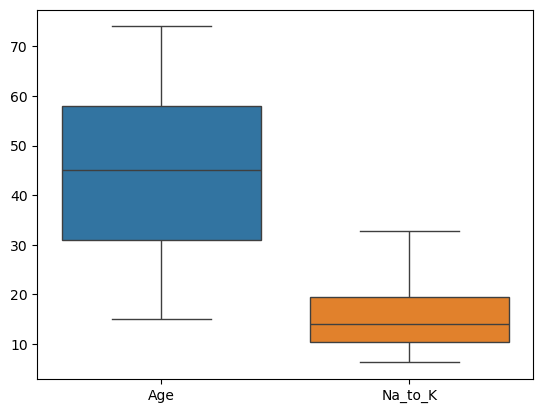

In [37]:
sns.boxplot(data=data)

<Axes: xlabel='Age', ylabel='Drug'>

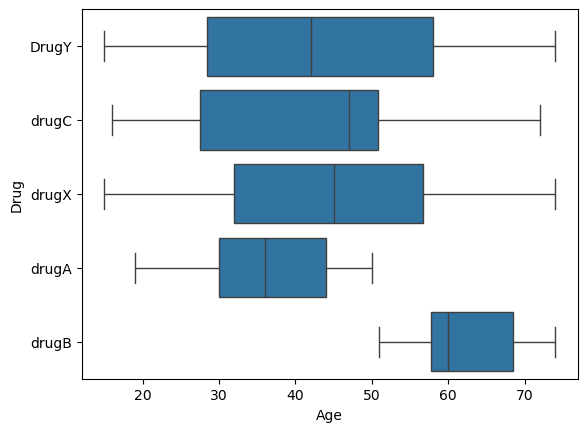

In [28]:
sns.boxplot(data=data,x='Age',y='Drug')

In [29]:
import numpy as np

for col in data.select_dtypes(include=np.number).columns:
    Q1 = data[col].quantile(0.25)
    Q3 = data[col].quantile(0.75)
    IQR = Q3 - Q1
    
    lower = Q1 - 1.5 * IQR
    upper = Q3 + 1.5 * IQR
    
    data[col] = np.where(data[col] < lower, lower,
              np.where(data[col] > upper, upper, data[col]))

mathematical intuition 
equation of hyperplane
w.x+b=0
w=weights
x=input
b=bias


In [35]:
X = data.drop("Drug", axis=1)   # input features
y = data["Drug"]   
X = pd.get_dummies(X)
             # target column

#split the data into training and testing sets
X_train, X_test, y_train, y_test = train_test_split(X, y,test_size=0.2, random_state=42)
#create an SVM model
svm_classifier=SVC(kernel='rbf',C=1.0,gamma='scale')
#train the model
svm_classifier.fit(X_train,y_train)
#make predictions
y_pred=svm_classifier.predict(X_test)
#evaluate the model
accuracy=accuracy_score(y_test,y_pred)
print(f'Accuracy: {accuracy:.2f}')

Accuracy: 0.62


In [36]:
from sklearn.datasets import load_iris
from sklearn.svm import SVC
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score


x=data.Age
y=data.Drug
x_train,x_test,y_train,y_test=train_test_split(x,y,test_size=0.2,random_state=42)
svm_classifier=SVC(kernel='rbf' #type  of boundary 
                   , C=1.0,gamma='scale')

x_train = x_train.values.reshape(-1, 1)
x_test = x_test.values.reshape(-1, 1)
svm_classifier.fit(x_train, y_train)
y_pred=svm_classifier.predict(x_test)
accuracy=accuracy_score(y_test,y_pred)
print("Accuracy:", accuracy)

Accuracy: 0.375


In [39]:
from sklearn.datasets import load_iris
from sklearn.svm import SVC
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score


x=data.Age
y=data.Drug
x_train,x_test,y_train,y_test=train_test_split(x,y,test_size=0.2,random_state=42)
svm_classifier=SVC(kernel='linear' #type  of boundary 
                   , C=1.0,gamma='scale')

x_train = x_train.values.reshape(-1, 1)
x_test = x_test.values.reshape(-1, 1)
svm_classifier.fit(x_train, y_train)
y_pred=svm_classifier.predict(x_test)
accuracy=accuracy_score(y_test,y_pred)
print(f"Accuracy: {accuracy:.2%}")

Accuracy: 37.50%
